## 1. Configuración e importación de librerías

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Estilo de las gráficas
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Librerías cargadas ✓")
print("pandas", pd.__version__, "| numpy", np.__version__)

Librerías cargadas ✓
pandas 2.2.3 | numpy 2.1.3


In [ ]:
# --- Rutas y diccionarios de referencia -------------------------------------

DATA_DIR = Path(".")

ARCHIVOS = {
    2024: DATA_DIR / "contaminantes_2024.csv",
    2025: DATA_DIR / "contaminantes_2025.csv",
    2026: DATA_DIR / "contaminantes_2026.csv",
}

# Nombre y unidad de cada contaminante
CONTAMINANTES = {
    "CO":    ("Monóxido de carbono",                 "ppm"),
    "NO":    ("Óxido nítrico",                        "ppb"),
    "NO2":   ("Dióxido de nitrógeno",                "ppb"),
    "NOX":   ("Óxidos de nitrógeno (NO+NO₂)",        "ppb"),
    "O3":    ("Ozono",                                "ppb"),
    "SO2":   ("Dióxido de azufre",                   "ppb"),
    "PM10":  ("Partículas ≤10 µm",                   "µg/m³"),
    "PM2.5": ("Partículas ≤2.5 µm",                  "µg/m³"),
    "PMCO":  ("Partículas gruesas (PM10−PM2.5)",     "µg/m³"),
}

# Código numérico de la columna 'unit' -> unidad legible
UNIDADES_COD = {1: "ppb", 2: "µg/m³", 15: "ppm"}

# Diccionario (parcial) de estaciones RAMA
ESTACIONES = {
    "ACO": "Acolman", "AJM": "Ajusco Medio", "AJU": "Ajusco", "ATI": "Atizapán",
    "BJU": "Benito Juárez", "CAM": "Camarones", "CCA": "Centro Ciencias Atmósfera (UNAM)",
    "CHO": "Chalco", "CUA": "Cuajimalpa", "CUT": "Cuautitlán", "FAC": "FES Acatlán",
    "FAR": "FES Aragón", "GAM": "Gustavo A. Madero", "HGM": "Hospital General",
    "INN": "Investigaciones Nucleares", "IZT": "Iztacalco", "LLA": "Los Laureles",
    "LPR": "La Presa", "MER": "Merced", "MGH": "Miguel Hidalgo", "MON": "Montecillo",
    "MPA": "Milpa Alta", "NEZ": "Nezahualcóyotl", "PED": "Pedregal",
    "SAC": "Santiago Acahualtepec", "SAG": "San Agustín", "SFE": "Santa Fe",
    "TAH": "Tláhuac", "TLA": "Tlalnepantla", "TLI": "Tultitlán", "UAX": "UAM Xochimilco",
    "UIZ": "UAM Iztapalapa", "VIF": "Villa de las Flores", "XAL": "Xalostoc",
}

print("Configuración lista ✓  |  Años:", list(ARCHIVOS))

Configuración lista ✓  |  Años: [2024, 2025, 2026]


## 2. ETL — Ingesta

Escribimos una función de lectura robusta que detecta automáticamente el encabezado
real y normaliza los nombres de columna. Luego unimos las tres
fuentes en un solo DataFrame.


In [ ]:
def leer_csv_contaminantes(ruta, anio):
    # Lee un CSV de SIMAT saltando los metadatos y normalizando columnas.
    ruta = Path(ruta)

    # 1) Detectar en qué línea está el encabezado real ("date", ...)
    fila_encabezado = None
    with open(ruta, "r", encoding="latin-1") as f:
        for i, linea in enumerate(f):
            l = linea.lstrip().lower().replace('"', "")
            if l.startswith("date") and "id_station" in l:
                fila_encabezado = i
                break
    if fila_encabezado is None:
        raise ValueError(f"No se encontró el encabezado en {ruta.name}")

    # 2) Leer desde el encabezado en adelante
    df = pd.read_csv(ruta, skiprows=fila_encabezado, encoding="latin-1")

    # 3) Normalizar nombres: 'valor' -> 'value', quitar espacios
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={"valor": "value"})

    # 4) Trazabilidad de la fuente
    df["anio_fuente"] = anio
    df["archivo_fuente"] = ruta.name

    print(f"  {ruta.name:28s} -> {len(df):>9,} filas | encabezado en línea {fila_encabezado+1}")
    return df


print("Leyendo archivos...")
frames = [leer_csv_contaminantes(ruta, anio) for anio, ruta in ARCHIVOS.items()]

Leyendo archivos...
  contaminantes_2024.csv       -> 2,430,675 filas | encabezado en línea 10
  contaminantes_2025.csv       -> 2,530,182 filas | encabezado en línea 10
  contaminantes_2026.csv       ->   433,296 filas | encabezado en línea 10


In [ ]:
# --- Concatenar las tres fuentes en un solo DataFrame ----------------------
df = pd.concat(frames, ignore_index=True)
del frames  # liberar memoria

print(f"\nDataFrame consolidado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()


DataFrame consolidado: 5,394,153 filas × 7 columnas


,date,id_station,id_parameter,value,unit,anio_fuente,archivo_fuente
0,2024-01-01 01:00:00,ACO,CO,NaN,15.000,2024,contaminantes_2024.csv
1,2024-01-01 01:00:00,ACO,NO,NaN,1.000,2024,contaminantes_2024.csv
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.000,2024,contaminantes_2024.csv
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.000,2024,contaminantes_2024.csv
4,2024-01-01 01:00:00,ACO,O3,NaN,1.000,2024,contaminantes_2024.csv


In [ ]:
# Verificación rápida de la ingesta: ¿cuántas filas aportó cada año?
df["anio_fuente"].value_counts().sort_index()

,count
anio_fuente,
2024,2430675
2025,2530182
2026,433296


## 3. ETL — Limpieza




In [ ]:
# 3.1 Tipos de dato
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# La columna 'unit' es un CÓDIGO -> la guardamos como código y su versión legible
df = df.rename(columns={"unit": "unit_cod"})
df["unit_cod"] = pd.to_numeric(df["unit_cod"], errors="coerce")
df["unidad"] = df["unit_cod"].map(UNIDADES_COD)

# Categorías (ahorran memoria y ordenan el análisis)
df["id_station"] = df["id_station"].astype("category")
df["id_parameter"] = df["id_parameter"].astype("category")

df.dtypes

,0
date,datetime64[ns]
id_station,category
id_parameter,category
value,float64
unit_cod,float64
anio_fuente,int64
archivo_fuente,object
unidad,object


In [ ]:
# 3.2 Diagnóstico de valores faltantes en la medición (columna 'value')
total = len(df)
faltantes = df["value"].isna().sum()
print(f"Registros totales : {total:,}")
print(f"Valores faltantes : {faltantes:,}  ({faltantes/total:.1%})")
print(f"Valores válidos   : {total-faltantes:,}  ({1-faltantes/total:.1%})")

print("\n% de valores faltantes por año de origen:")
(df.groupby("anio_fuente")["value"]
   .apply(lambda s: s.isna().mean()*100)
   .round(1).astype(str).add(" %"))

Registros totales : 5,394,153
Valores faltantes : 2,357,916  (43.7%)
Valores válidos   : 3,036,237  (56.3%)

% de valores faltantes por año de origen:


,value
anio_fuente,
2024,42.3 %
2025,43.6 %
2026,51.9 %


In [ ]:
# 3.3 Duplicados exactos (misma fecha, estación y parámetro)
dups = df.duplicated(subset=["date", "id_station", "id_parameter"]).sum()
print(f"Filas duplicadas (fecha+estación+parámetro): {dups:,}")

# 3.4 Valores imposibles: una concentración negativa no tiene sentido físico
negativos = (df["value"] < 0).sum()
print(f"Valores negativos (inválidos): {negativos:,}")

# Marcamos los negativos como faltantes (ruido de calibración de las estaciones)
df.loc[df["value"] < 0, "value"] = np.nan

Filas duplicadas (fecha+estación+parámetro): 100,551
Valores negativos (inválidos): 1


In [ ]:
# 3.5 Decisión de tratamiento de nulos

# construimos un DataFrame de trabajo SOLO con lecturas válidas y dejamos el
# 'df' completo intacto para poder auditar los huecos si hiciera falta.
df_valido = df.dropna(subset=["value"]).copy()

print(f"df (crudo consolidado): {len(df):,} filas")
print(f"df_valido (para stats): {len(df_valido):,} filas")

df (crudo consolidado): 5,394,153 filas
df_valido (para stats): 3,036,236 filas


## 4. ETL — Feature Engineering

Creamos columnas nuevas que enriquecen el análisis y permiten comparar por periodo:

anio, mes, dia, hora, dia_semana a partir de la fecha.
contaminante (nombre legible) para reportes.

Nota: usamos anio derivado de la fecha real (no del nombre del archivo) para que el análisis
sea a prueba de errores de origen.


In [ ]:
for base in (df, df_valido):
    base["anio"] = base["date"].dt.year
    base["mes"] = base["date"].dt.month
    base["dia"] = base["date"].dt.day
    base["hora"] = base["date"].dt.hour
    base["dia_semana"] = base["date"].dt.day_name()

mapa_nombre = {k: v[0] for k, v in CONTAMINANTES.items()}
df_valido["contaminante"] = df_valido["id_parameter"].map(mapa_nombre)

df_valido[["date", "anio", "mes", "hora", "id_station",
           "id_parameter", "contaminante", "value", "unidad"]].head()

,date,anio,mes,hora,id_station,id_parameter,contaminante,value,unidad
7,2024-01-01 01:00:00,"2,024.000",1.000,1.000,AJM,CO,Monóxido de carbono,0.230,ppm
8,2024-01-01 01:00:00,"2,024.000",1.000,1.000,AJM,NO,Óxido nítrico,0.000,ppb
9,2024-01-01 01:00:00,"2,024.000",1.000,1.000,AJM,NO2,Dióxido de nitrógeno,10.000,ppb
10,2024-01-01 01:00:00,"2,024.000",1.000,1.000,AJM,NOX,Óxidos de nitrógeno (NO+NO₂),10.000,ppb
11,2024-01-01 01:00:00,"2,024.000",1.000,1.000,AJM,O3,Ozono,43.000,ppb


In [ ]:
# Cobertura temporal real de cada año (clave: 2026 está incompleto)
(df_valido.groupby("anio")
          .agg(desde=("date", "min"),
               hasta=("date", "max"),
               meses=("mes", "nunique"),
               lecturas=("value", "size")))

,desde,hasta,meses,lecturas
anio,,,,
"2,024.000",2024-01-01 01:00:00,2024-12-31 23:00:00,12,1347430
"2,025.000",2025-01-01 00:00:00,2025-12-31 23:00:00,12,1425789
"2,026.000",2026-01-01 00:00:00,2026-02-28 23:00:00,2,208322


> El archivo de 2026 solo contiene enero y febrero. Cualquier
> comparación *anual directa* contra 2024 y 2025 (que tienen 12 meses) sería injusta. Más abajo
> hacemos también una comparación acotada a enero–febrero para los tres años, que sí es
> comparable "manzanas con manzanas".


## 5. Análisis exploratorio

¿Qué contaminantes y estaciones hay, y cuántas lecturas válidas tiene cada uno?


In [ ]:
# Lecturas válidas por contaminante y año (tabla dinámica)
tabla_conteos = (df_valido
    .pivot_table(index="id_parameter", columns="anio",
                 values="value", aggfunc="count", observed=True)
    .astype("Int64"))
print("Número de lecturas válidas por contaminante y año:")
tabla_conteos

Número de lecturas válidas por contaminante y año:


anio,"2,024.000","2,025.000","2,026.000"
id_parameter,,,
CO,176213,197279,27013
NO,154386,166558,24796
NO2,175962,190758,26908
NOX,154386,166289,24759
O3,214941,219831,32241
PM10,120001,129530,19468
PM2.5,107320,100655,14908
PMCO,68250,66040,9956
SO2,175971,188849,28273


In [ ]:
# 5.1 Moda de las columnas CATEGÓRICAS (tratamiento según tipo de columna)
print("Contaminante más medido (moda):", df_valido["id_parameter"].mode()[0])
print("Estación más activa (moda)   :",
      df_valido["id_station"].mode()[0],
      "->", ESTACIONES.get(df_valido["id_station"].mode()[0], "?"))

print("\nTop 5 estaciones por número de lecturas válidas:")
top_est = df_valido["id_station"].value_counts().head(5)
top_est.index = [f"{c} ({ESTACIONES.get(c,'?')})" for c in top_est.index]
top_est

Contaminante más medido (moda): O3
Estación más activa (moda)   : MER -> Merced

Top 5 estaciones por número de lecturas válidas:


,count
MER (Merced),149413
AJM (Ajusco Medio),145645
PED (Pedregal),145046
TLA (Tlalnepantla),135070
UIZ (UAM Iztapalapa),128295


## 6. Medidas de tendencia central y de dispersión

Tendencia central: media, mediana, moda.
Dispersión: varianza y desviación estándar (más rango como apoyo).


In [ ]:
def moda_segura(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

resumen = (df_valido
    .groupby(["anio", "id_parameter"], observed=True)["value"]
    .agg(n="count",
         media="mean",
         mediana="median",
         moda=moda_segura,
         varianza="var",
         desv_std="std",
         minimo="min",
         maximo="max")
    .round(3)
    .reset_index())

print("Medidas de tendencia central y dispersión por año y contaminante:")
resumen

Medidas de tendencia central y dispersión por año y contaminante:


,anio,id_parameter,n,media,mediana,moda,varianza,desv_std,minimo,maximo
0,"2,024.000",CO,176213,0.473,0.360,0.250,0.171,0.414,0.000,5.440
1,"2,024.000",NO,154386,13.757,3.000,1.000,830.663,28.821,0.000,498.000
2,"2,024.000",NO2,175962,23.383,21.000,14.000,195.041,13.966,0.000,140.000
3,"2,024.000",NOX,154386,37.216,25.000,14.000,"1,417.297",37.647,0.000,569.000
4,"2,024.000",O3,214941,33.057,26.000,1.000,803.709,28.350,0.000,187.000
5,"2,024.000",PM10,120001,43.500,38.000,26.000,824.321,28.711,1.000,582.000
6,"2,024.000",PM2.5,107320,20.549,18.000,15.000,176.136,13.272,1.000,312.000
7,"2,024.000",PMCO,68250,19.451,17.000,6.000,214.489,14.645,1.000,304.000
8,"2,024.000",SO2,175971,2.588,1.000,1.000,23.262,4.823,0.000,185.000
9,"2,025.000",CO,197279,0.524,0.440,0.300,0.145,0.381,0.000,6.090


In [ ]:
# 6.1 Comparación directa de la media por año (una fila por contaminante)
comparativa_media = (resumen
    .pivot(index="id_parameter", columns="anio", values="media")
    .round(2))
comparativa_media["Δ 25-24"] = (comparativa_media[2025] - comparativa_media[2024]).round(2)
comparativa_media["% cambio 25/24"] = (
    (comparativa_media[2025] / comparativa_media[2024] - 1) * 100).round(1)
print("MEDIA por contaminante y año (año completo):")
comparativa_media

MEDIA por contaminante y año (año completo):


anio,"2,024.000","2,025.000","2,026.000",Δ 25-24,% cambio 25/24
id_parameter,,,,,
CO,0.470,0.520,0.790,0.050,10.600
NO,13.760,11.580,20.400,-2.180,-15.800
NO2,23.380,21.960,29.540,-1.420,-6.100
NOX,37.220,34.220,49.760,-3.000,-8.100
O3,33.060,32.510,31.580,-0.550,-1.700
PM10,43.500,38.850,52.090,-4.650,-10.700
PM2.5,20.550,19.630,25.610,-0.920,-4.500
PMCO,19.450,16.020,19.950,-3.430,-17.600
SO2,2.590,2.820,7.000,0.230,8.900


In [ ]:
# 6.2 Lo mismo para la DESVIACIÓN ESTÁNDAR (¿la variabilidad es parecida entre años?)
comparativa_std = (resumen
    .pivot(index="id_parameter", columns="anio", values="desv_std")
    .round(2))
print("DESVIACIÓN ESTÁNDAR por contaminante y año:")
comparativa_std

DESVIACIÓN ESTÁNDAR por contaminante y año:


anio,"2,024.000","2,025.000","2,026.000"
id_parameter,,,
CO,0.410,0.380,0.560
NO,28.820,23.620,37.900
NO2,13.970,12.670,16.100
NOX,37.650,31.530,47.440
O3,28.350,28.010,29.230
PM10,28.710,25.830,33.170
PM2.5,13.270,11.770,17.170
PMCO,14.640,13.630,15.000
SO2,4.820,5.220,11.510


## 7. Visualización de distribuciones

Graficamos la distribución de cada contaminante y superponemos los tres años para verlos juntos.
Para que las colas extremas (posibles atípicos de estaciones descalibradas) no aplasten las
gráficas, recortamos la vista al percentil 99 de cada contaminante.


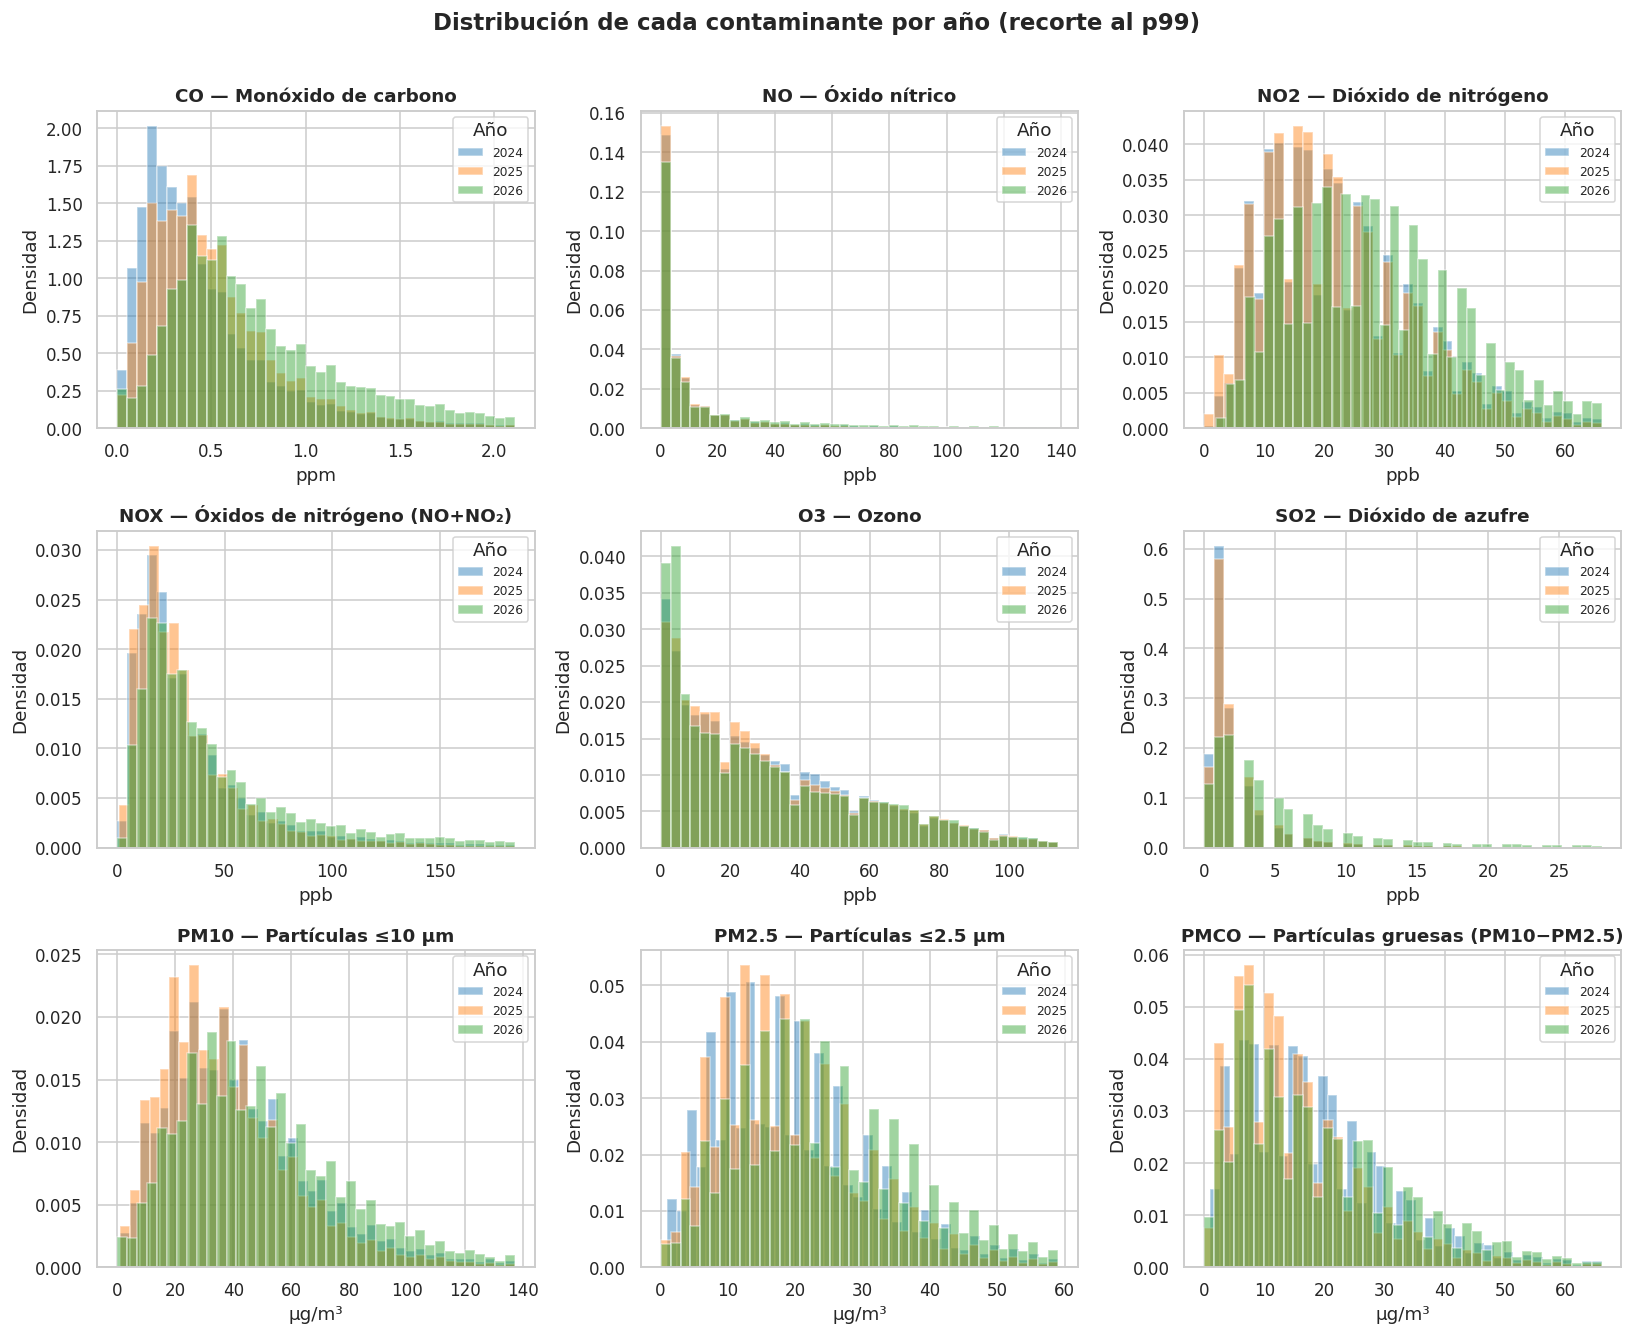

In [ ]:
parametros = list(CONTAMINANTES.keys())
colores = {2024: "#1f77b4", 2025: "#ff7f0e", 2026: "#2ca02c"}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, p in zip(axes.ravel(), parametros):
    sub = df_valido[df_valido["id_parameter"] == p]
    if sub.empty:
        ax.set_visible(False)
        continue
    lim = sub["value"].quantile(0.99)
    for anio in sorted(sub["anio"].dropna().unique()):
        datos = sub.loc[sub["anio"] == anio, "value"]
        datos = datos[datos <= lim]
        ax.hist(datos, bins=40, alpha=0.45, density=True,
                label=str(int(anio)), color=colores.get(anio))
    nombre, unidad = CONTAMINANTES[p]
    ax.set_title(f"{p} — {nombre}")
    ax.set_xlabel(unidad)
    ax.set_ylabel("Densidad")
    ax.legend(title="Año", fontsize=8)

fig.suptitle("Distribución de cada contaminante por año (recorte al p99)",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

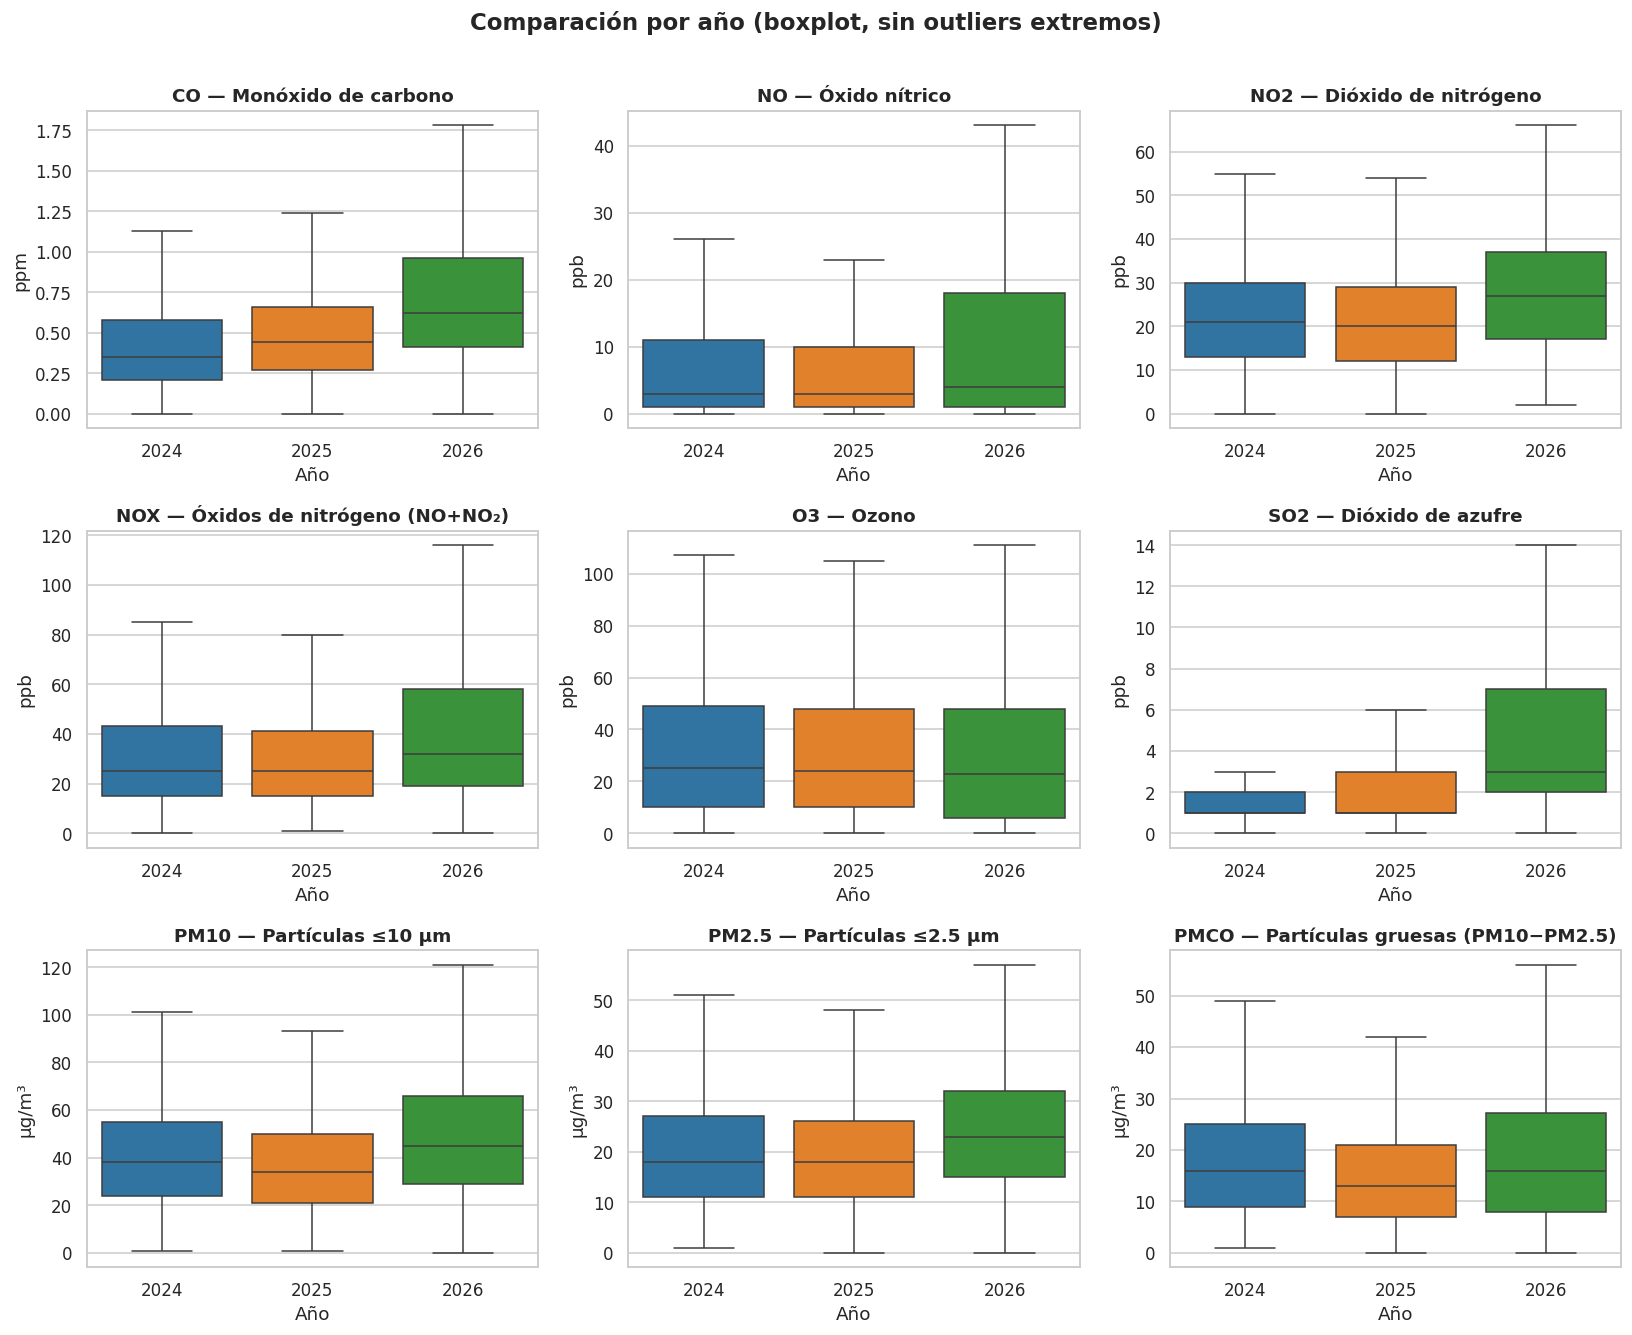

In [ ]:
# 7.1 Boxplots: comparación de nivel y dispersión por año
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, p in zip(axes.ravel(), parametros):
    sub = df_valido[df_valido["id_parameter"] == p]
    if sub.empty:
        ax.set_visible(False)
        continue
    lim = sub["value"].quantile(0.99)
    sub = sub[sub["value"] <= lim].dropna(subset=["anio"]).copy()
    sub["anio"] = sub["anio"].astype(int)
    sns.boxplot(data=sub, x="anio", y="value", hue="anio",
                palette=colores, legend=False, ax=ax, showfliers=False)
    nombre, unidad = CONTAMINANTES[p]
    ax.set_title(f"{p} — {nombre}")
    ax.set_xlabel("Año")
    ax.set_ylabel(unidad)

fig.suptitle("Comparación por año (boxplot, sin outliers extremos)",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

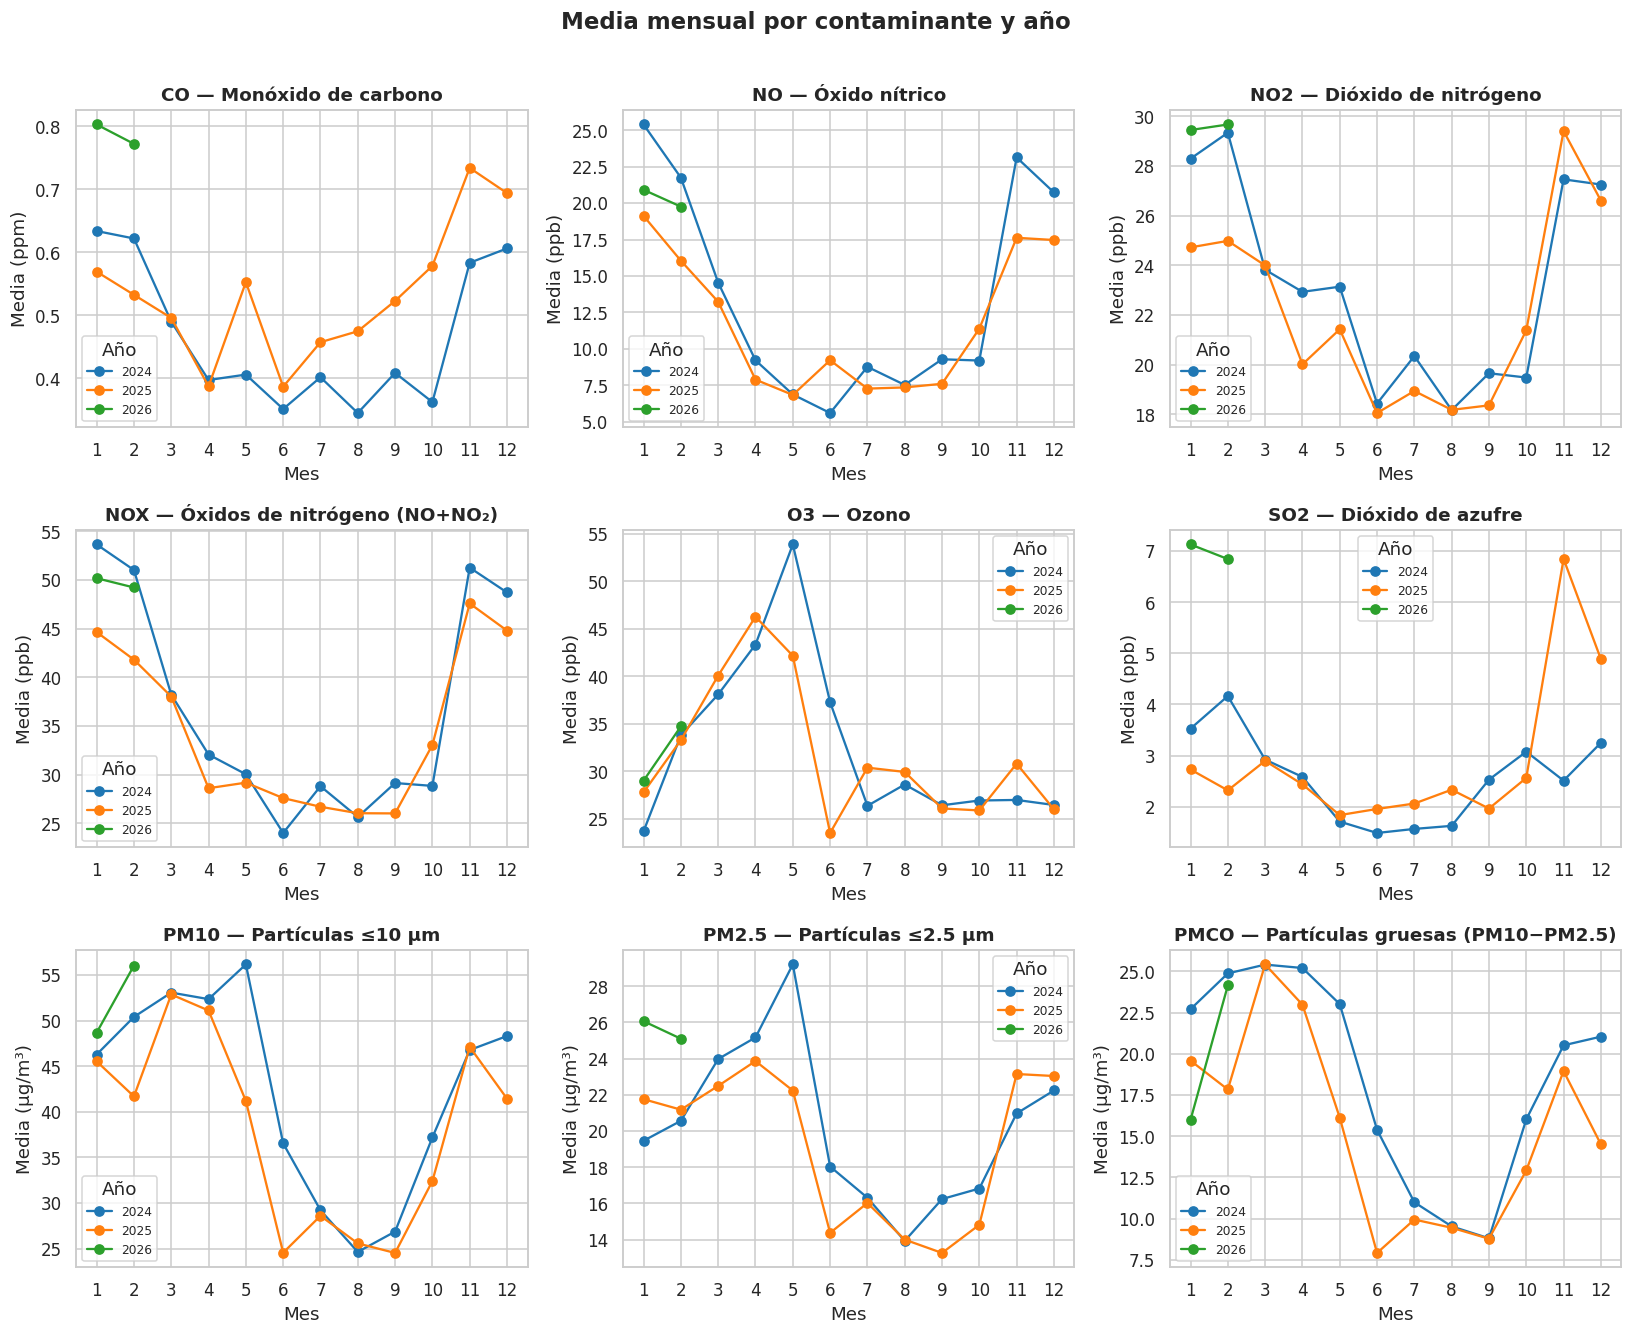

In [ ]:
# 7.2 Ciclo mensual promedio: ¿los años siguen el mismo patrón estacional?
prom_mes = (df_valido.groupby(["id_parameter", "anio", "mes"], observed=True)["value"]
                     .mean().reset_index())

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, p in zip(axes.ravel(), parametros):
    sub = prom_mes[prom_mes["id_parameter"] == p]
    if sub.empty:
        ax.set_visible(False)
        continue
    for anio in sorted(sub["anio"].unique()):
        s = sub[sub["anio"] == anio]
        ax.plot(s["mes"], s["value"], marker="o", label=str(int(anio)),
                color=colores.get(anio))
    nombre, unidad = CONTAMINANTES[p]
    ax.set_title(f"{p} — {nombre}")
    ax.set_xlabel("Mes")
    ax.set_ylabel(f"Media ({unidad})")
    ax.set_xticks(range(1, 13))
    ax.legend(title="Año", fontsize=8)

fig.suptitle("Media mensual por contaminante y año", fontsize=15,
             fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 8. Comparación justa: solo enero–febrero

Como 2026 solo tiene los dos primeros meses, comparamos los mismos meses (enero y febrero)
en los tres años


In [ ]:
ene_feb = df_valido[df_valido["mes"].isin([1, 2])]

resumen_ef = (ene_feb.groupby(["anio", "id_parameter"], observed=True)["value"]
    .agg(n="count", media="mean", mediana="median",
         desv_std="std").round(2).reset_index())

media_ef = resumen_ef.pivot(index="id_parameter", columns="anio", values="media").round(2)
print("MEDIA ene–feb por contaminante (comparable entre los 3 años):")
media_ef

MEDIA ene–feb por contaminante (comparable entre los 3 años):


anio,"2,024.000","2,025.000","2,026.000"
id_parameter,,,
CO,0.630,0.550,0.790
NO,23.580,17.600,20.400
NO2,28.800,24.850,29.540
NOX,52.350,43.250,49.760
O3,28.770,30.500,31.580
PM10,48.220,43.620,52.090
PM2.5,20.020,21.460,25.610
PMCO,23.750,18.660,19.950
SO2,3.840,2.530,7.000


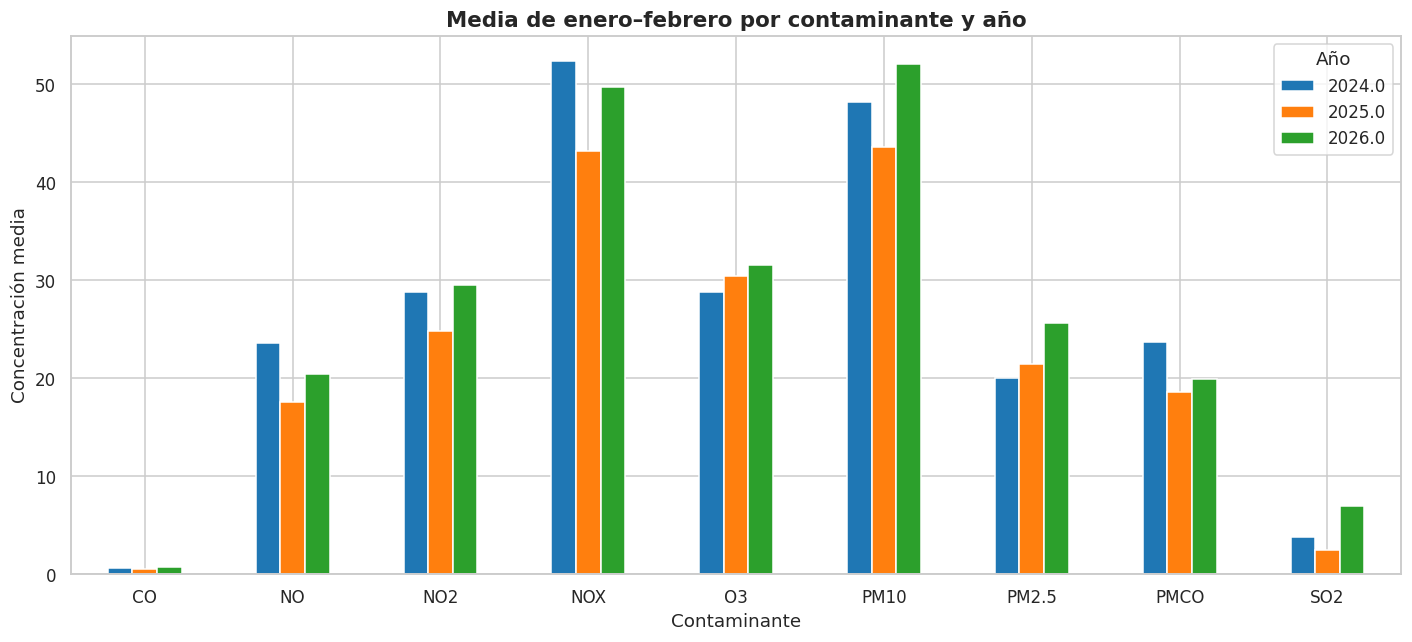

In [ ]:
# Gráfica de barras agrupadas: media ene-feb por contaminante y año
fig, ax = plt.subplots(figsize=(13, 6))
media_ef.plot(kind="bar", ax=ax, color=[colores.get(a) for a in media_ef.columns])
ax.set_title("Media de enero–febrero por contaminante y año", fontsize=14)
ax.set_xlabel("Contaminante")
ax.set_ylabel("Concentración media")
ax.legend(title="Año")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Variación % de la media ene-feb respecto a 2024 (medida de congruencia)
base24 = media_ef[2024]
variacion = pd.DataFrame({
    "% cambio 2025 vs 2024": ((media_ef[2025] / base24 - 1) * 100).round(1),
    "% cambio 2026 vs 2024": ((media_ef[2026] / base24 - 1) * 100).round(1),
})
print("Cambio porcentual de la media (enero–febrero) respecto a 2024:")
variacion

Cambio porcentual de la media (enero–febrero) respecto a 2024:


,% cambio 2025 vs 2024,% cambio 2026 vs 2024
id_parameter,,
CO,-12.700,25.400
NO,-25.400,-13.500
NO2,-13.700,2.600
NOX,-17.400,-4.900
O3,6.000,9.800
PM10,-9.500,8.000
PM2.5,7.200,27.900
PMCO,-21.400,-16.000
SO2,-34.100,82.300


## 9. Conclusiones

Sobre el proceso (ETL):

- Las tres fuentes se integraron en un solo DataFrame pese a venir con encabezados,
  nombres de columna (value vs valor) y codificación distintos. Detectar el encabezado de
  forma automática fue clave para que la ingesta fuera reproducible.
- La gran mayoría de los huecos no son un error: son horas en que una estación no reporta un
  contaminante dado. Se optó por descartar los nulos para el cálculo estadístico (imputar con
  la media habría reducido artificialmente la varianza).
- Se detectó y anuló un pequeño número de valores negativos (imposibles físicamente,
  atribuibles a calibración de los equipos).

Sobre la congruencia entre años:

- En la comparación enero–febrero, las medias de los contaminantes
  se mantienen en el mismo orden de magnitud entre 2024, 2025 y 2026, y las distribuciones y
  el ciclo mensual conservan la misma forma. Esto es consistente con la hipótesis de que, al
  no haber una política ambiental nueva, los años deberían parecerse.
- Las diferencias que sí aparecen son las esperables por variabilidad meteorológica (los meses
  fríos concentran más partículas y CO por inversiones térmicas) y no por un cambio estructural.
- Salvedad metodológica: 2026 está incompleto (solo 2 meses), así que no debe
  compararse su promedio anual contra el de los años completos. Además, se observó que 2024
  guarda los valores redondeados a enteros mientras 2025/2026 los traen con dos decimales:
  una diferencia de precisión de captura, no de calidad del aire.
